In [1]:
import os
import json
import random
import shutil
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import Counter
from collections import defaultdict

### Create new folder for augmented dataset

donc dabord on check si ca existe deja, puis ensuite on cree le nouveau folder

In [2]:
DATA_DIR = "symbols_dataset"
OUT_DIR = "augm_symbols_dataset"

In [3]:
# Safety check: output folder already exists?

if os.path.exists(OUT_DIR):
    raise FileExistsError(f"'{OUT_DIR}' already exists. Aborting to avoid overwriting.")

# create output folder
os.makedirs(OUT_DIR)

### Count symbols

on va compter cmb ya de symboles de chaque dans le dataset original pour pouvoir separer 10-90% de chaque dans train et test

In [4]:
with open(os.path.join(DATA_DIR, "labels.json"), "r") as f:
    labels = json.load(f)

class_counts = Counter()

for img, label in labels.items():
    class_counts[label] += 1

for label, count in sorted(class_counts.items()):
    print(label, count)

0 54
1 69
2 96
3 85
4 107
5 84
6 68
7 123
8 104
9 48
draw_2 62
draw_4 23
reverse 60
skip 62
wild 45


### 90-10% separation of the dataset respectively for training and testing

Stratified split: Split a dataset into train (90%) and test (10%), while keeping each class balanced in both sets.

In [5]:
# Group images by class = symbol
by_class = defaultdict(list)

for img, label in labels.items(): #reorganizes data from image->label to label->list of images
    by_class[label].append(img)

# create json for train and test sets
train_labels = {}
test_labels = {}

random.seed(42) #same shuffle every time you run the code -> reproducible dataset split

# Stratified split (90/10)
for label, images in by_class.items():
    random.shuffle(images) #Shuffle images inside each class -> shuffle makes split random inside each class.

    n_test = int(len(images) * 0.1) #choose repartition 10-90%

    test_imgs = images[:n_test] #been shuffled, so if you take 1st 10% its random
    train_imgs = images[n_test:]

    #restore initial format
    for img in train_imgs: 
        train_labels[img] = labels[img]

    for img in test_imgs:
        test_labels[img] = labels[img]

# Summary
print("Total:", len(labels))
print("Train:", len(train_labels))
print("Test:", len(test_labels))

# Save in json
with open(os.path.join(OUT_DIR, "train.json"), "w") as f:
    json.dump(train_labels, f, indent=2)

with open(os.path.join(OUT_DIR, "test.json"), "w") as f:
    json.dump(test_labels, f, indent=2)

Total: 1090
Train: 988
Test: 102


### Add original images to the folder

In [7]:
# Load datasets (train + test already exist in OUT_DIR)
#loading your already-created dataset splits from disk into Python dictionaries so you can use them in code.

with open(os.path.join(OUT_DIR, "train.json"), "r") as f:
    train_labels = json.load(f)

with open(os.path.join(OUT_DIR, "test.json"), "r") as f:
    test_labels = json.load(f)

In [8]:
# ----------------------------
# Copy original images once (no duplication)
# en vrai je pourrais juste tt dupliquer au debut mais bon disons que comme ca on est surs que ya que les images de train et test meme si chaque imageg est censee etre dans lune ou lautre
# ----------------------------
all_images = list(train_labels.keys()) + list(test_labels.keys()) #make one list containing every image in test or train 

for img_name in tqdm(all_images): #loop over each image, tqdm adds progressive bar
    src = os.path.join(DATA_DIR, img_name) #path to original image
    dst = os.path.join(OUT_DIR, img_name) #destination path

    if not os.path.exists(dst): #prevent copying if already there
        shutil.copy(src, dst)

100%|█████████████████████████████████████| 1090/1090 [00:00<00:00, 3240.01it/s]


In [12]:
# check that theres the right number of images in the augmneted dataset file
def count_files(folder):
    num_images = 0
    num_json = 0

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        if os.path.isfile(path):
            if file.endswith((".png", ".jpg", ".jpeg", ".bmp")):
                num_images += 1
            elif file.endswith(".json"):
                num_json += 1

    return num_images, num_json


# Count original dataset
orig_images, orig_json = count_files(DATA_DIR)

# Count augmented dataset
aug_images, aug_json = count_files(OUT_DIR)

print("=== ORIGINAL DATASET ===")
print(f"Images in {DATA_DIR}: {orig_images}")
print(f"JSON files in {DATA_DIR}: {orig_json}")

print("\n=== AUGMENTED DATASET ===")
print(f"Images in {OUT_DIR}: {aug_images}")
print(f"JSON files in {OUT_DIR}: {aug_json}")

=== ORIGINAL DATASET ===
Images in symbols_dataset: 1090
JSON files in symbols_dataset: 1

=== AUGMENTED DATASET ===
Images in augm_symbols_dataset: 1090
JSON files in augm_symbols_dataset: 2


### Augment dataset function

In [21]:
def augment_image(img):
    # random rotation
    angle = random.uniform(0, 360) # chiffre sur carte peut etre dans nimporte quel sens 

    # random translation
    tx = random.uniform(-10, 10)
    ty = random.uniform(-10, 10)
    # chiffre est cense etre centre mais a cause ombre ou autre ca peut etre un peu shift, dc on fait translation mais de tres peu

    aug_img = img.rotate(angle, resample=Image.BILINEAR)

    aug_img = aug_img.transform(
        img.size,
        Image.AFFINE,
        (1, 0, tx, 0, 1, ty),
        resample=Image.BILINEAR
    )

    return aug_img, angle, tx, ty

Example avec rotations et translations

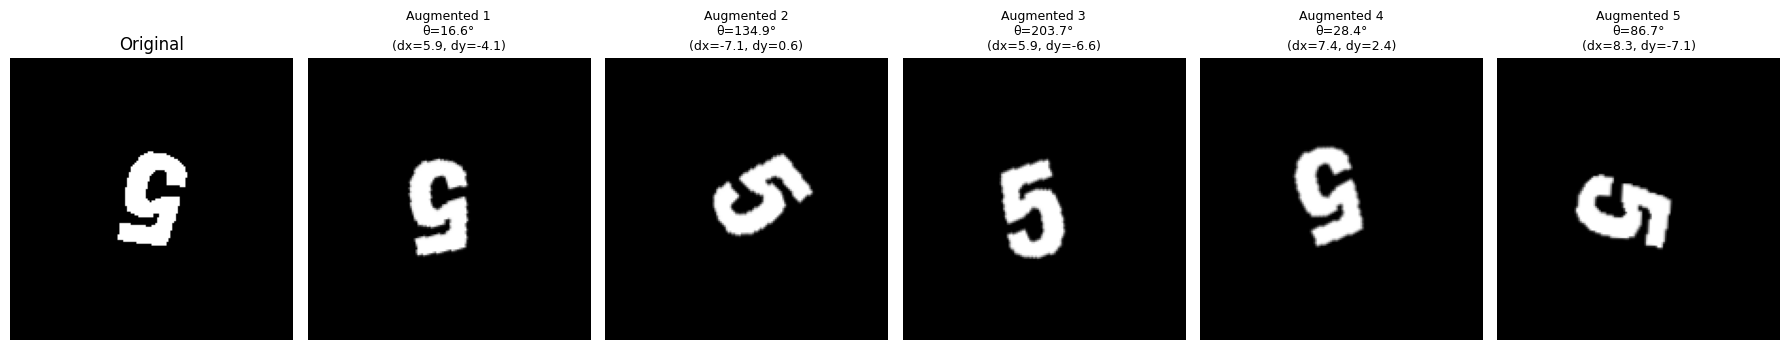

In [22]:
sample_img_name = list(train_labels.keys())[0]

fig, axes = plt.subplots(1, 6, figsize=(18, 5))

# original
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

# 5 augmentations
for i in range(5):
    aug, angle, tx, ty = augment_image(img)

    axes[i + 1].imshow(aug)
    axes[i + 1].set_title(
        f"Augmented {i+1}\nθ={angle:.1f}°\n(dx={tx:.1f}, dy={ty:.1f})",
        fontsize=9
    )
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

ajoute de remettre en binaire dns la fonction et mentionner que cest a cause de linteroplation

### Augmentation of the dataset

In [27]:
# on veut que chaque symbol soit represente le meme nombre de fois dans un meme set. et avec ces nb on a que 11% de test (pas 10% sinon serait pas nb entier), et 6000 de train en tt.
# faire une fonction pour ca
TRAIN_TARGET = 400
TEST_TARGET = 44

In [28]:
# PRINT ORIGINAL DISTRIBUTION
def print_dist(name, labels):
    c = Counter(labels.values())
    total = sum(c.values())

    print(f"\n{name}")
    for k in sorted(c.keys()):
        print(f"{k}: {c[k]}")
    print("TOTAL:", total)


print_dist("TRAIN original", train_labels)
print_dist("TEST original", test_labels)


TRAIN original
0: 49
1: 63
2: 87
3: 77
4: 97
5: 76
6: 62
7: 111
8: 94
9: 44
draw_2: 56
draw_4: 21
reverse: 54
skip: 56
wild: 41
TOTAL: 988

TEST original
0: 5
1: 6
2: 9
3: 8
4: 10
5: 8
6: 6
7: 12
8: 10
9: 4
draw_2: 6
draw_4: 2
reverse: 6
skip: 6
wild: 4
TOTAL: 102


In [34]:
# FIND START INDEX
# figure out the next available filename index so that newly augmented images don’t overwrite existing ones.

max_index = 0
for f in list(train_labels.keys()) + list(test_labels.keys()):
    try:
        max_index = max(max_index, int(f.replace("symbol_", "").replace(".png", "")))
    except:
        pass

new_index = max_index + 1

In [35]:
# OUTPUT LABELS (we KEEP originals + add new ones)
# modify or extend your dataset labels without touching the originals.

new_train = dict(train_labels)
new_test = dict(test_labels)

In [36]:
# GROUP BY CLASS

def group_by_class(labels):
    d = defaultdict(list)
    for img, label in labels.items():
        d[label].append(img)
    return d


train_by_class = group_by_class(train_labels)
test_by_class = group_by_class(test_labels)

In [39]:
# TRAIN COMPLETION (ONLY MISSING DATA)

print("\nGenerating TRAIN (completion mode)...")

for c in train_by_class:
    imgs = train_by_class[c]

    current_count = len(imgs)
    needed = max(0, TRAIN_TARGET - current_count)

    print(f"Class {c}: {current_count} → adding {needed}")

    for _ in tqdm(range(needed)):
        src = random.choice(imgs)

        img = Image.open(os.path.join(DATA_DIR, src)).convert("RGB")

        aug, angle, tx, ty = augment_image(img)  # 👈 FIX HERE

        name = f"symbol_{new_index}.png"
        aug.save(os.path.join(OUT_DIR, name))

        new_train[name] = train_labels[src]
        new_index += 1


Generating TRAIN (completion mode)...
Class 5: 76 → adding 324


100%|████████████████████████████████████████| 324/324 [00:00<00:00, 384.59it/s]


Class 2: 87 → adding 313


100%|████████████████████████████████████████| 313/313 [00:00<00:00, 380.58it/s]


Class 8: 94 → adding 306


...

100%|████████████████████████████████████████| 379/379 [00:01<00:00, 313.66it/s]


Class wild: 41 → adding 359


100%|████████████████████████████████████████| 359/359 [00:00<00:00, 377.30it/s]


Class skip: 56 → adding 344


100%|████████████████████████████████████████| 344/344 [00:00<00:00, 380.93it/s]


In [40]:
# TEST COMPLETION (ONLY MISSING DATA)

print("\nGenerating TEST (completion mode)...")

for c, imgs in test_by_class.items():

    current_count = len(imgs)
    needed = max(0, TEST_TARGET - current_count)

    print(f"Class {c}: {current_count} → adding {needed}")

    for _ in tqdm(range(needed)):
        src = random.choice(imgs)

        img = Image.open(os.path.join(DATA_DIR, src)).convert("RGB")

        aug, angle, tx, ty = augment_image(img)  # FIX: unpack tuple

        name = f"symbol_{new_index}.png"
        aug.save(os.path.join(OUT_DIR, name))

        new_test[name] = test_labels[src]
        new_index += 1


Generating TEST (completion mode)...
Class 5: 8 → adding 36


100%|██████████████████████████████████████████| 36/36 [00:00<00:00, 288.75it/s]


Class 2: 9 → adding 35


100%|██████████████████████████████████████████| 35/35 [00:00<00:00, 392.81it/s]


Class 8: 10 → adding 34


...

100%|██████████████████████████████████████████| 42/42 [00:00<00:00, 370.52it/s]


Class wild: 4 → adding 40


100%|██████████████████████████████████████████| 40/40 [00:00<00:00, 377.86it/s]


Class skip: 6 → adding 38


100%|██████████████████████████████████████████| 38/38 [00:00<00:00, 366.00it/s]


In [41]:
# SAVE JSONS
# save updated dataset

with open(f"{OUT_DIR}/train.json", "w") as f:
    json.dump(new_train, f, indent=2)

with open(f"{OUT_DIR}/test.json", "w") as f:
    json.dump(new_test, f, indent=2)

In [44]:
def stats(name, labels, image_dir):
    # count labels from JSON
    label_counts = Counter(labels.values())

    # count actual images in folder
    image_files = [
        f for f in os.listdir(image_dir)
        if f.endswith(".png")
    ]

    print(f"\n{name} FINAL")

    # print label counts
    print("\nLabels (from JSON):")
    for k in sorted(label_counts.keys()):
        print(f"{k}: {label_counts[k]}")

    # print image count per class (from filenames if encoded)
    print("\nImages (in folder):")
    print(f"Total images: {len(image_files)}")

    print("TOTAL LABELS:", sum(label_counts.values()))


# usage
stats("TRAIN", new_train, OUT_DIR)
stats("TEST", new_test, OUT_DIR)


TRAIN FINAL

Labels (from JSON):
0: 400
1: 400
2: 400
3: 400
4: 400
5: 400
6: 400
7: 400
8: 400
9: 400
draw_2: 400
draw_4: 400
reverse: 400
skip: 400
wild: 400

Images (in folder):
Total images: 6660
TOTAL LABELS: 6000

TEST FINAL

Labels (from JSON):
0: 44
1: 44
2: 44
3: 44
4: 44
5: 44
6: 44
7: 44
8: 44
9: 44
draw_2: 44
draw_4: 44
reverse: 44
skip: 44
wild: 44

Images (in folder):
Total images: 6660
TOTAL LABELS: 660
